<a href="https://colab.research.google.com/github/HitanshuGedam/quantum-learning-journey/blob/main/Day5_Density_Matrices_Mixed_States_Bloch_Ball.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 5: Density Matrices and Mixed States

## From Pure States to Statistical Ensembles

## Learning Objectives

By the end of this notebook, you will understand:

1. The density matrix formalism for quantum states
2. Difference between pure and mixed states
3. Convex combinations and statistical mixtures
4. The Bloch ball representation of mixed states
5. Purity and von Neumann entropy as measures of mixedness
6. How to simulate and visualize mixed states using QuTiP

## Philosophical Motivation

In real quantum systems, we rarely have perfect knowledge of a quantum state. Noise, decoherence, and imperfect preparation lead to statistical mixtures. The density matrix formalism provides the mathematical framework to describe these imperfect quantum states and forms the foundation for quantum information theory, open quantum systems, and quantum thermodynamics.


## References

- Nielsen & Chuang (2010). Quantum Computation and Quantum Information. Chapter 2.4.
- QuTiP Documentation: https://qutip.org

In [1]:
# ============================================================================
# SETUP AND INSTALLATIONS
# ============================================================================

!pip install qutip qutip_qip -q

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

print(f"NumPy version: {np.__version__}")
print(f"QuTiP version: {qt.__version__}")
print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.8/140.8 kB 9.1 MB/s eta 0:00:00
NumPy version: 2.0.2
QuTiP version: 5.2.3
Setup complete.


## 1. Why Density Matrices?

### Limitations of State Vectors

State vectors |ψ⟩ describe **pure states** - states we have complete knowledge about. However, in real experiments:

- We may not know the exact quantum state (statistical uncertainty)
- The system may be entangled with an environment (decoherence)
- We may be dealing with a statistical ensemble of states

### The Density Matrix Formalism

A density matrix ρ (rho) is a positive semi-definite, Hermitian operator with Tr(ρ) = 1 that completely describes a quantum state.

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Property</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Pure State</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Mixed State</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">Representation</td>
            <td style="padding: 8px;">|ψ⟩⟨ψ|</td>
            <td style="padding: 8px;">Σᵢ pᵢ |ψᵢ⟩⟨ψᵢ|</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Tr(ρ²)</td>
            <td style="padding: 8px;">1</td>
            <td style="padding: 8px;">&lt; 1</td>
        </tr>
        <tr>
            <td style="padding: 8px;">von Neumann Entropy</td>
            <td style="padding: 8px;">0</td>
            <td style="padding: 8px;">> 0</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Bloch Sphere</td>
            <td style="padding: 8px;">Surface (r = 1)</td>
            <td style="padding: 8px;">Interior (r &lt; 1)</td>
        </tr>
    </tbody>
</table>

### Purity Range

For a qubit (dimension n = 2), purity ranges from 1/2 to 1:
- **Pure states:** Tr(ρ²) = 1 (maximum)
- **Maximally mixed:** Tr(ρ²) = 1/2 (minimum)
- **Partially mixed:** 1/2 &lt; Tr(ρ²) &lt; 1

For a general d-dimensional system, purity ranges from 1/d to 1.

In [2]:
# ============================================================================
# CREATING PURE AND MIXED STATES
# ============================================================================

print("=" * 70)
print("PURE AND MIXED STATES")
print("=" * 70)

# Create a pure state |0⟩
ket0 = qt.basis(2, 0)
rho_pure = ket0 * ket0.dag()

# Create a maximally mixed state: I/2
rho_mixed = qt.qeye(2) / 2

print("\nPure state |0⟩⟨0|:")
print(rho_pure)
print(f"Trace: {rho_pure.tr():.1f}")
print(f"Purity: {(rho_pure * rho_pure).tr():.3f}")

print("\nMaximally mixed state I/2:")
print(rho_mixed)
print(f"Trace: {rho_mixed.tr():.1f}")
print(f"Purity: {(rho_mixed * rho_mixed).tr():.3f}")

# Create a statistical mixture: 75% |0⟩, 25% |1⟩
rho_mixture = 0.75 * (qt.basis(2, 0) * qt.basis(2, 0).dag()) + \
              0.25 * (qt.basis(2, 1) * qt.basis(2, 1).dag())

print("\nStatistical mixture: 75% |0⟩, 25% |1⟩:")
print(rho_mixture)
print(f"Trace: {rho_mixture.tr():.1f}")
print(f"Purity: {(rho_mixture * rho_mixture).tr():.3f}")

print("\n✅ Pure state: Tr(ρ²) = 1")
print("✅ Mixed state: Tr(ρ²) < 1")
print("✅ Maximally mixed: Tr(ρ²) = 1/2 for qubits")

PURE AND MIXED STATES

Pure state |0⟩⟨0|:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0.]
 [0. 0.]]
Trace: 1.0
Purity: 1.000

Maximally mixed state I/2:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0.5 0. ]
 [0.  0.5]]
Trace: 1.0
Purity: 0.500

Statistical mixture: 75% |0⟩, 25% |1⟩:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.75 0.  ]
 [0.   0.25]]
Trace: 1.0
Purity: 0.625

✅ Pure state: Tr(ρ²) = 1
✅ Mixed state: Tr(ρ²) < 1
✅ Maximally mixed: Tr(ρ²) = 1/2 for qubits


## 2. Convex Combinations

### Definition

A convex combination of density matrices is a mixture:

$$ \rho = \sum_i p_i \rho_i, \quad p_i \geq 0, \quad \sum_i p_i = 1 $$

### Geometric Interpretation

The set of all density matrices is convex:
- Pure states are **extremal points** (on the boundary)
- Mixed states are **interior points**
- Any mixed state can be written as a convex combination of pure states

### Important: Decomposition is NOT Unique

The same density matrix can be written as different convex combinations of pure states. For example, the maximally mixed state:

$$ \frac{I}{2} = \frac{1}{2}|0\rangle\langle0| + \frac{1}{2}|1\rangle\langle1| = \frac{1}{2}|+\rangle\langle+| + \frac{1}{2}|-\rangle\langle-| $$

These are physically different ensembles that produce the same density matrix. This is the **Hughston-Jozsa-Wootters theorem** — the density matrix contains less information than the ensemble.

### Examples

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Mixture</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Formula</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Purity</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">Pure</td>
            <td style="padding: 8px;">|ψ⟩⟨ψ|</td>
            <td style="padding: 8px;">1</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Maximally mixed</td>
            <td style="padding: 8px;">I/2</td>
            <td style="padding: 8px;">0.5</td>
        </tr>
        <tr>
            <td style="padding: 8px;">75% |0⟩, 25% |1⟩</td>
            <td style="padding: 8px;">0.75|0⟩⟨0| + 0.25|1⟩⟨1|</td>
            <td style="padding: 8px;">0.625</td>
        </tr>
        <tr>
            <td style="padding: 8px;">50% |+⟩, 50% |-⟩</td>
            <td style="padding: 8px;">0.5|+⟩⟨+| + 0.5|-⟩⟨-|</td>
            <td style="padding: 8px;">0.5</td>
        </tr>
    </tbody>
</table>

Refer:
[Wikipedia article](https://en.wikipedia.org/wiki/Quantum_state_purification)

In [4]:
# ============================================================================
# CONVEX COMBINATIONS DEMONSTRATION
# ============================================================================

print("=" * 70)
print("CONVEX COMBINATIONS")
print("=" * 70)

# Define pure states
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)
ket_plus = (ket0 + ket1).unit()
ket_minus = (ket0 - ket1).unit()

# Pure states
rho0 = ket0 * ket0.dag()
rho1 = ket1 * ket1.dag()
rho_plus = ket_plus * ket_plus.dag()
rho_minus = ket_minus * ket_minus.dag()

print("\nDifferent mixtures with same outcome probabilities:")
print("-" * 60)

# Mixture 1: 50% |0⟩, 50% |1⟩
rho_mix1 = 0.5 * rho0 + 0.5 * rho1
purity1 = (rho_mix1 * rho_mix1).tr().real

# Mixture 2: 50% |+⟩, 50% |-⟩
rho_mix2 = 0.5 * rho_plus + 0.5 * rho_minus
purity2 = (rho_mix2 * rho_mix2).tr().real

print(f"Mixture 1 (50% |0⟩, 50% |1⟩):")
print(f"  {rho_mix1}")
print(f"  Purity = {purity1:.4f}")
# Access matrix elements correctly using .full()
print(f"  Probability of |0⟩ = {rho_mix1.full()[0, 0].real:.2f}")

print(f"\nMixture 2 (50% |+⟩, 50% |-⟩):")
print(f"  {rho_mix2}")
print(f"  Purity = {purity2:.4f}")
print(f"  Probability of |0⟩ = {rho_mix2.full()[0, 0].real:.2f}")

print("\n✅ Both mixtures give the SAME density matrix I/2!")
print("✅ This demonstrates that decomposition is NOT unique")
print("✅ Different physical ensembles can yield identical density matrices")

# Create mixtures with different purities
print("\n" + "=" * 60)
print("MIXTURES WITH DIFFERENT PURITIES")
print("=" * 60)

weights = [0, 0.25, 0.5, 0.75, 1.0]
for w in weights:
    rho = (1 - w) * rho0 + w * rho1
    purity = (rho * rho).tr().real
    print(f"{(1-w)*100:.0f}% |0⟩, {w*100:.0f}% |1⟩: Purity = {purity:.4f}")

CONVEX COMBINATIONS

Different mixtures with same outcome probabilities:
------------------------------------------------------------
Mixture 1 (50% |0⟩, 50% |1⟩):
  Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.5 0. ]
 [0.  0.5]]
  Purity = 0.5000
  Probability of |0⟩ = 0.50

Mixture 2 (50% |+⟩, 50% |-⟩):
  Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0. ]
 [0.  0.5]]
  Purity = 0.5000
  Probability of |0⟩ = 0.50

✅ Both mixtures give the SAME density matrix I/2!
✅ This demonstrates that decomposition is NOT unique
✅ Different physical ensembles can yield identical density matrices

MIXTURES WITH DIFFERENT PURITIES
100% |0⟩, 0% |1⟩: Purity = 1.0000
75% |0⟩, 25% |1⟩: Purity = 0.6250
50% |0⟩, 50% |1⟩: Purity = 0.5000
25% |0⟩, 75% |1⟩: Purity = 0.6250
0% |0⟩, 100% |1⟩: Purity = 1.0000


## 3. The Bloch Ball

### Bloch Sphere vs Bloch Ball

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Region</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">States</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Bloch Vector Length</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Purity</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">Surface (r = 1)</td>
            <td style="padding: 8px;">Pure states</td>
            <td style="padding: 8px;">|r| = 1</td>
            <td style="padding: 8px;">Tr(ρ²) = 1</td>
        </tr>
         <tr>
            <td style="padding: 8px;">Interior (r &lt; 1)</td>
            <td style="padding: 8px;">Mixed states</td>
            <td style="padding: 8px;">|r| &lt; 1</td>
            <td style="padding: 8px;">Tr(ρ²) &lt; 1</td>
        </tr>
         <tr>
            <td style="padding: 8px;">Center (r = 0)</td>
            <td style="padding: 8px;">Maximally mixed</td>
            <td style="padding: 8px;">r = 0</td>
            <td style="padding: 8px;">Tr(ρ²) = 1/2</td>
        </tr>
    </tbody>
</table>

### Bloch Vector Representation

For any qubit state:

$$ \rho = \frac{1}{2}(I + \vec{r} \cdot \vec{\sigma}) $$

where $\vec{r} = (r_x, r_y, r_z)$ is the Bloch vector with $|\vec{r}| \leq 1$

### Visualization

The Bloch ball shows:
- **Surface:** Pure states (maximally coherent)
- **Interior:** Mixed states (partially decohered)
- **Center:** Maximally mixed state (complete decoherence)

BLOCH BALL VISUALIZATION

States at different radii (same direction):
--------------------------------------------------
r = 1.00: Bloch vector = (1.00, 0.00, 0.00), Purity = 1.000
r = 0.75: Bloch vector = (0.75, 0.00, 0.00), Purity = 0.781
r = 0.50: Bloch vector = (0.50, 0.00, 0.00), Purity = 0.625
r = 0.25: Bloch vector = (0.25, 0.00, 0.00), Purity = 0.531
r = 0.00: Bloch vector = (0.00, 0.00, 0.00), Purity = 0.500


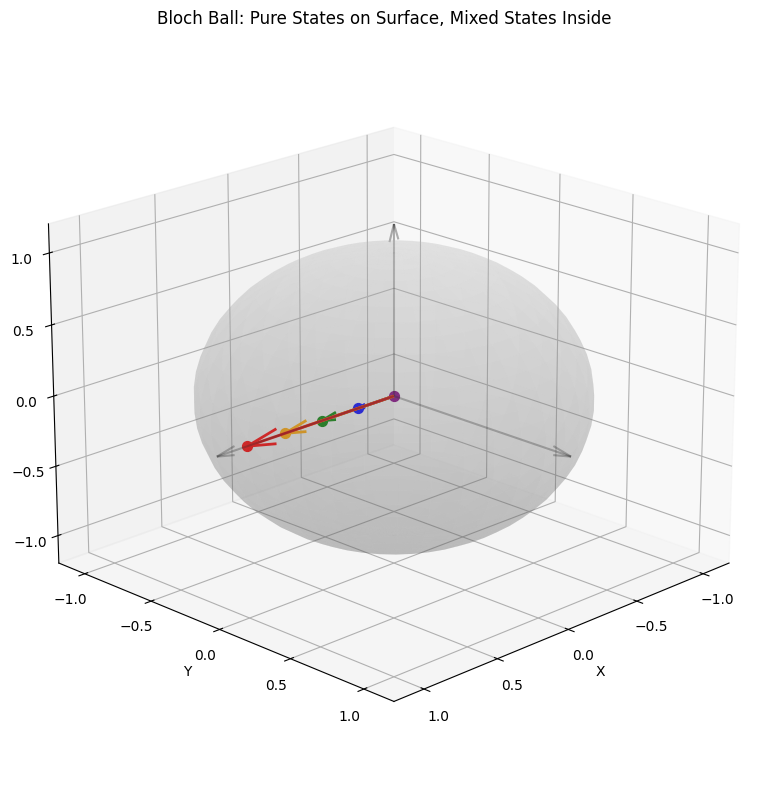


Observation:
- r = 1.0: Pure state on surface (|+⟩)
- r = 0.75, 0.5, 0.25: Mixed states inside the sphere
- r = 0.0: Maximally mixed state at center
- As purity decreases, the Bloch vector shrinks toward the center


In [6]:
# ============================================================================
# BLOCH BALL VISUALIZATION
# ============================================================================

print("=" * 70)
print("BLOCH BALL VISUALIZATION")
print("=" * 70)

def bloch_vector(rho):
    """Extract Bloch vector from density matrix (ensuring real values)."""
    rho_mat = rho.full()
    rx = 2 * np.real(rho_mat[0, 1])
    ry = 2 * np.imag(rho_mat[0, 1])
    rz = np.real(rho_mat[0, 0] - rho_mat[1, 1])
    # Ensure real values (remove tiny imaginary parts)
    return np.array([float(rx), float(ry), float(rz)])

# Create states at different radii
colors = ['red', 'orange', 'green', 'blue', 'purple']

print("\nStates at different radii (same direction):")
print("-" * 50)

# Create figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw Bloch sphere surface
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:30j]
x_sphere = np.cos(u) * np.sin(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(v)
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightgray', alpha=0.2, edgecolor='none')

# Draw axes
ax.quiver(0, 0, 0, 1.2, 0, 0, color='black', arrow_length_ratio=0.1, alpha=0.3)
ax.quiver(0, 0, 0, 0, 1.2, 0, color='black', arrow_length_ratio=0.1, alpha=0.3)
ax.quiver(0, 0, 0, 0, 0, 1.2, color='black', arrow_length_ratio=0.1, alpha=0.3)

# Create states at different radii along +X direction
radii = [1.0, 0.75, 0.5, 0.25, 0.0]
for idx, r in enumerate(radii):
    # Create density matrix: ρ = (I + rX)/2
    rho = 0.5 * (qt.qeye(2) + r * qt.sigmax())
    vec = bloch_vector(rho)
    # Ensure vector is real
    vec = np.array([float(v) for v in vec])
    ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], color=colors[idx],
              arrow_length_ratio=0.2, linewidth=2)
    ax.scatter([vec[0]], [vec[1]], [vec[2]], color=colors[idx], s=50)
    purity_val = (rho * rho).tr().real
    print(f"r = {r:.2f}: Bloch vector = ({vec[0]:.2f}, {vec[1]:.2f}, {vec[2]:.2f}), Purity = {purity_val:.3f}")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Bloch Ball: Pure States on Surface, Mixed States Inside")
ax.view_init(elev=20, azim=45)
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])

plt.tight_layout()
plt.show()

print("\nObservation:")
print("- r = 1.0: Pure state on surface (|+⟩)")
print("- r = 0.75, 0.5, 0.25: Mixed states inside the sphere")
print("- r = 0.0: Maximally mixed state at center")
print("- As purity decreases, the Bloch vector shrinks toward the center")

## 4. Purity and von Neumann Entropy

### Purity

$$ \text{Purity} = \text{Tr}(\rho^2) $$

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">State</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Purity</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">Pure</td>
            <td style="padding: 8px;">1</td>
        </tr>
         <tr>
            <td style="padding: 8px;">Mixed</td>
            <td style="padding: 8px;">&lt; 1</td>
        </tr>
         <tr>
            <td style="padding: 8px;">Maximally mixed (qubit)</td>
            <td style="padding: 8px;">1/2</td>
        </tr>
    </tbody>
</table>

### von Neumann Entropy

$$ S(\rho) = -\text{Tr}(\rho \log \rho) $$

<table style="width: 100%; border-collapse: collapse;">
    <thead>
         <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">State</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">von Neumann Entropy</th>
         </tr>
    </thead>
    <tbody>
         <tr>
            <td style="padding: 8px;">Pure</td>
            <td style="padding: 8px;">0</td>
         </tr>
         <tr>
            <td style="padding: 8px;">Mixed</td>
            <td style="padding: 8px;">> 0</td>
         </tr>
         <tr>
            <td style="padding: 8px;">Maximally mixed (qubit)</td>
            <td style="padding: 8px;">1 (using log₂)</td>
         </tr>
    </tbody>
</table>

### Relationship

Purity and entropy are inversely related measures of mixedness:
- Higher purity → Lower entropy
- Lower purity → Higher entropy

PURITY AND VON NEUMANN ENTROPY

r          Purity          Entropy        
----------------------------------------
0.00       0.5000          1.0000         
0.10       0.5050          0.9928         
0.20       0.5200          0.9710         
0.30       0.5450          0.9341         
0.40       0.5800          0.8813         
0.50       0.6250          0.8113         
0.60       0.6800          0.7219         
0.70       0.7450          0.6098         
0.80       0.8200          0.4690         
0.90       0.9050          0.2864         
1.00       1.0000          -0.0000        


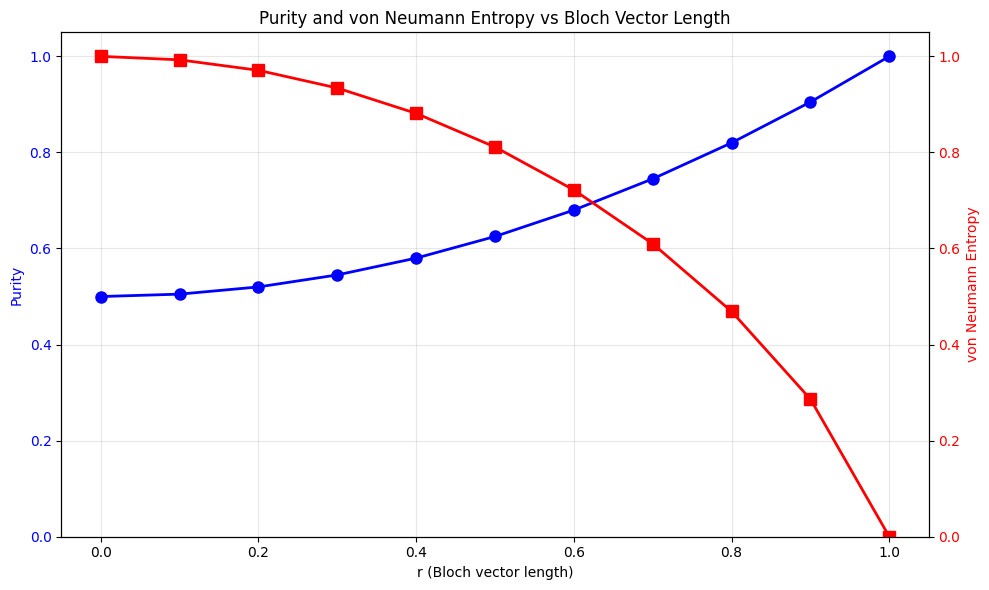


Observations:
- Pure state (r=1): Purity = 1, Entropy = 0
- Maximally mixed (r=0): Purity = 0.5, Entropy = 1
- Purity decreases as entropy increases
- The relationship is monotonic: more mixed = higher entropy


In [7]:
# ============================================================================
# PURITY AND VON NEUMANN ENTROPY
# ============================================================================

print("=" * 70)
print("PURITY AND VON NEUMANN ENTROPY")
print("=" * 70)

def purity(rho):
    """Calculate purity of a density matrix."""
    return (rho * rho).tr().real

def entropy(rho):
    """Calculate von Neumann entropy of a density matrix."""
    evals = rho.eigenenergies()
    # Filter out zero eigenvalues to avoid log(0)
    evals = evals[evals > 1e-12]
    return -np.sum(evals * np.log2(evals))

# Create states along the line from pure to maximally mixed
radii = np.linspace(0, 1, 11)
purities = []
entropies = []

print(f"\n{'r':<10} {'Purity':<15} {'Entropy':<15}")
print("-" * 40)

for r in radii:
    # State: ρ = (I + rX)/2
    rho = 0.5 * (qt.qeye(2) + r * qt.sigmax())
    p = purity(rho)
    e = entropy(rho)
    purities.append(p)
    entropies.append(e)
    print(f"{r:<10.2f} {p:<15.4f} {e:<15.4f}")

# Plot purity and entropy vs radius
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot purity
color = 'blue'
ax1.set_xlabel('r (Bloch vector length)')
ax1.set_ylabel('Purity', color=color)
ax1.plot(radii, purities, 'o-', color=color, linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim([0, 1.05])
ax1.grid(True, alpha=0.3)

# Plot entropy on second y-axis
ax2 = ax1.twinx()
color = 'red'
ax2.set_ylabel('von Neumann Entropy', color=color)
ax2.plot(radii, entropies, 's-', color=color, linewidth=2, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim([0, 1.05])

plt.title('Purity and von Neumann Entropy vs Bloch Vector Length')
plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Pure state (r=1): Purity = 1, Entropy = 0")
print("- Maximally mixed (r=0): Purity = 0.5, Entropy = 1")
print("- Purity decreases as entropy increases")
print("- The relationship is monotonic: more mixed = higher entropy")

## 5. Density Matrices for Composite Systems

### Reduced Density Matrices

For a bipartite quantum state $ \rho_{AB} $, the reduced density matrix for subsystem $ A $ is:

$
\rho_A = \mathrm{Tr}_B(\rho_{AB})
$

where $ \mathrm{Tr}_B $ denotes the **partial trace** over subsystem $ B $.

---

### What is the Partial Trace?

The partial trace is an operation that **removes (or ignores) one subsystem**, leaving the state of the remaining subsystem.

It is the **unique operation** that preserves all measurement statistics for observables acting only on the remaining subsystem.

---

### How to Calculate the Partial Trace

For a composite Hilbert space $ \mathcal{H}_A \otimes \mathcal{H}_B $:

#### Action on product operators:
$
\mathrm{Tr}_B(A \otimes B) = A \cdot \mathrm{Tr}(B)
$

---

#### General matrix form (in basis $ \{ |i_A\rangle \otimes |j_B\rangle \} $):

$
(\rho_A)_{ik} = \sum_j \rho_{(i,j),(k,j)}
$

where the sum runs over the basis states of subsystem $ B $.

---

### Example: Bell State

$
|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}
$

#### Global density matrix:

$
\rho_{AB} = |\Phi^+\rangle \langle \Phi^+|
= \frac{1}{2} \left(
|00\rangle\langle00| +
|00\rangle\langle11| +
|11\rangle\langle00| +
|11\rangle\langle11|
\right)
$

---

### Computing $ \rho_A = \mathrm{Tr}_B(\rho_{AB}) $

Rule:
- For a term $ |i_A j_B\rangle \langle k_A l_B| $:
  - Contributes only if $ j_B = l_B $
  - Then becomes $ |i_A\rangle \langle k_A| $

---

#### Contributions:

- $ |00\rangle\langle00| \rightarrow |0\rangle\langle0| $
- $ |11\rangle\langle11| \rightarrow |1\rangle\langle1| $
- $ |00\rangle\langle11| \rightarrow 0 $
- $ |11\rangle\langle00| \rightarrow 0 $

---

#### Final result:

$
\rho_A = \frac{1}{2} \left(|0\rangle\langle0| + |1\rangle\langle1|\right) = \frac{I}{2}
$

---

### Methods to Calculate Partial Trace

<table style="width:100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align:left; padding:8px; background-color:#f2f2f2;">Method</th>
<th style="text-align:left; padding:8px; background-color:#f2f2f2;">Description</th>
<th style="text-align:left; padding:8px; background-color:#f2f2f2;">When to Use</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding:8px;">Manual Summation</td>
<td style="padding:8px;">Sum over basis states of traced-out subsystem</td>
<td style="padding:8px;">Small systems, analytical work</td>
</tr>
<tr>
<td style="padding:8px;">QuTiP <code>ptrace()</code></td>
<td style="padding:8px;">Built-in function for partial trace</td>
<td style="padding:8px;">Numerical simulations</td>
</tr>
<tr>
<td style="padding:8px;">Matrix Reshaping</td>
<td style="padding:8px;">Reshape tensor indices and sum appropriately</td>
<td style="padding:8px;">Custom implementations</td>
</tr>
<tr>
<td style="padding:8px;">Schmidt Decomposition</td>
<td style="padding:8px;">Use Schmidt coefficients directly</td>
<td style="padding:8px;">Pure bipartite states</td>
</tr>
</tbody>
</table>

---

### Properties of the Partial Trace

<table style="width:100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align:left; padding:8px; background-color:#f2f2f2;">Property</th>
<th style="text-align:left; padding:8px; background-color:#f2f2f2;">Formula</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding:8px;">Linearity</td>
<td style="padding:8px;">$ \mathrm{Tr}_B(a\rho + b\sigma) = a\,\mathrm{Tr}_B(\rho) + b\,\mathrm{Tr}_B(\sigma) $</td>
</tr>
<tr>
<td style="padding:8px;">Trace Preservation</td>
<td style="padding:8px;">$ \mathrm{Tr}(\mathrm{Tr}_B(\rho)) = \mathrm{Tr}(\rho) $</td>
</tr>
<tr>
<td style="padding:8px;">Positivity</td>
<td style="padding:8px;">If $ \rho \geq 0 $, then $ \mathrm{Tr}_B(\rho) \geq 0 $</td>
</tr>
<tr>
<td style="padding:8px;">Consistency</td>
<td style="padding:8px;">$ \mathrm{Tr}_B(\rho_A \otimes \rho_B) = \rho_A \cdot \mathrm{Tr}(\rho_B) $</td>
</tr>
</tbody>
</table>

---

### Entanglement and Mixedness

For a pure entangled state (e.g., Bell state):

- Global state:
$
\mathrm{Tr}(\rho_{AB}^2) = 1, \quad S(\rho_{AB}) = 0
$

- Reduced states:
$
\mathrm{Tr}(\rho_A^2) = \frac{1}{2}, \quad S(\rho_A) = 1
$

---

### Key Insight

Local mixedness can arise from global purity due to **entanglement**.

$
\text{Information is not lost — it is stored in correlations.}
$

---

### Interpretation for Bell State

$
|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}
$

<table style="width:100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align:left; padding:8px; background-color:#f2f2f2;">Aspect</th>
<th style="text-align:left; padding:8px; background-color:#f2f2f2;">Description</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding:8px;">Global state</td>
<td style="padding:8px;">Pure (zero entropy)</td>
</tr>
<tr>
<td style="padding:8px;">Subsystems</td>
<td style="padding:8px;">Maximally mixed</td>
</tr>
<tr>
<td style="padding:8px;">Information</td>
<td style="padding:8px;">Stored entirely in correlations</td>
</tr>
</tbody>
</table>

---

### Final Insight

$
\text{Entanglement = perfect correlations with no local information}
$

In [8]:
# ============================================================================
# REDUCED DENSITY MATRICES AND ENTANGLEMENT
# ============================================================================

print("=" * 70)
print("REDUCED DENSITY MATRICES")
print("=" * 70)

def purity(rho):
    """Calculate purity of a density matrix."""
    return (rho * rho).tr().real

def entropy(rho):
    """Calculate von Neumann entropy of a density matrix."""
    evals = rho.eigenenergies()
    # Filter out zero eigenvalues to avoid log(0)
    evals = evals[evals > 1e-12]
    return -np.sum(evals * np.log2(evals))

# Create Bell state |Φ⁺⟩
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)
ket00 = qt.tensor(ket0, ket0)
ket11 = qt.tensor(ket1, ket1)
bell_state = (ket00 + ket11).unit()

# Global density matrix
rho_global = bell_state * bell_state.dag()

# Reduced density matrices
rho_A = rho_global.ptrace(0)
rho_B = rho_global.ptrace(1)

print("\nBell state |Φ⁺⟩ = (|00⟩ + |11⟩)/√2")
print(f"\nGlobal state purity: {purity(rho_global):.4f}")
print(f"Global state entropy: {entropy(rho_global):.4f}")

print(f"\nReduced state for qubit A:")
print(rho_A)
print(f"Purity: {purity(rho_A):.4f}")
print(f"Entropy: {entropy(rho_A):.4f}")

print(f"\nReduced state for qubit B:")
print(rho_B)
print(f"Purity: {purity(rho_B):.4f}")
print(f"Entropy: {entropy(rho_B):.4f}")

print("\n" + "=" * 70)
print("KEY INSIGHT")
print("=" * 70)
print("""
- Global state is pure (Purity = 1, Entropy = 0)
- Reduced states are maximally mixed (Purity = 0.5, Entropy = 1)
- Local mixedness comes from global entanglement!
- Information is stored in correlations, not locally
""")
print("=" * 70)

REDUCED DENSITY MATRICES

Bell state |Φ⁺⟩ = (|00⟩ + |11⟩)/√2

Global state purity: 1.0000
Global state entropy: 0.0000

Reduced state for qubit A:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.5 0. ]
 [0.  0.5]]
Purity: 0.5000
Entropy: 1.0000

Reduced state for qubit B:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.5 0. ]
 [0.  0.5]]
Purity: 0.5000
Entropy: 1.0000

KEY INSIGHT

- Global state is pure (Purity = 1, Entropy = 0)
- Reduced states are maximally mixed (Purity = 0.5, Entropy = 1)
- Local mixedness comes from global entanglement!
- Information is stored in correlations, not locally



## 6. Summary and Key Insights

### Density Matrix Properties

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Property</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Condition</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">Hermiticity</td>
            <td style="padding: 8px;">$\rho = \rho^\dagger$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Positivity</td>
            <td style="padding: 8px;">$\langle\psi|\rho|\psi\rangle \geq 0$ for all $|\psi\rangle$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Trace</td>
            <td style="padding: 8px;">$\text{Tr}(\rho) = 1$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Purity</td>
            <td style="padding: 8px;">$0 < \text{Tr}(\rho^2) \leq 1$ (for qubits, minimum $1/2$)</td>
        </tr>
    </tbody>
</table>

### Bloch Ball Summary

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Region</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Purity</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Bloch Vector Length</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Examples</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">Surface</td>
            <td style="padding: 8px;">$1$</td>
            <td style="padding: 8px;">$1$</td>
            <td style="padding: 8px;">$|0\rangle$, $|+\rangle$, $|i\rangle$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Interior</td>
            <td style="padding: 8px;">$< 1$</td>
            <td style="padding: 8px;">$< 1$</td>
            <td style="padding: 8px;">Mixed states</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Center</td>
            <td style="padding: 8px;">$1/2$</td>
            <td style="padding: 8px;">$0$</td>
            <td style="padding: 8px;">$I/2$</td>
        </tr>
    </tbody>
</table>

### Key Formulas

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Formula</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Name</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">$\rho = \sum_i p_i |\psi_i\rangle\langle\psi_i|$</td>
            <td style="padding: 8px;">Density matrix</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$\text{Tr}(\rho^2)$</td>
            <td style="padding: 8px;">Purity</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$S(\rho) = -\text{Tr}(\rho \log \rho)$</td>
            <td style="padding: 8px;">von Neumann entropy</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$\rho = \frac{1}{2}(I + \vec{r} \cdot \vec{\sigma})$</td>
            <td style="padding: 8px;">Bloch representation</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$\rho_A = \text{Tr}_B(\rho_{AB})$</td>
            <td style="padding: 8px;">Reduced density matrix</td>
        </tr>
    </tbody>
</table>

### Key Takeaways

1. **Density matrices** describe both pure and mixed quantum states
2. **Pure states**: $\text{Tr}(\rho^2) = 1$, $S(\rho) = 0$, on Bloch sphere surface
3. **Mixed states**: $\text{Tr}(\rho^2) < 1$, $S(\rho) > 0$, inside Bloch ball
4. **Convex combinations** create mixed states from pure states
5. **Decomposition is NOT unique** — different ensembles can give the same density matrix (Hughston-Jozsa-Wootters theorem)
6. **Reduced density matrices** describe subsystems of entangled states
7. **Local mixedness** can arise from global entanglement

---

**Day 5 Complete!** 🎉

You now understand:
- The density matrix formalism for quantum states
- Difference between pure and mixed states
- Convex combinations and statistical mixtures
- The Bloch ball representation of mixed states
- Purity and von Neumann entropy as measures of mixedness
- Reduced density matrices and their connection to entanglement
- The non-uniqueness of density matrix decomposition

Proceed to Day 6 when ready.